[*********************100%***********************]  1 of 1 completed

Epoch 1/100



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Train

<ipython-input-20-e7f66bfcfcb0>:116: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  novo_datetime = pd.date_range(


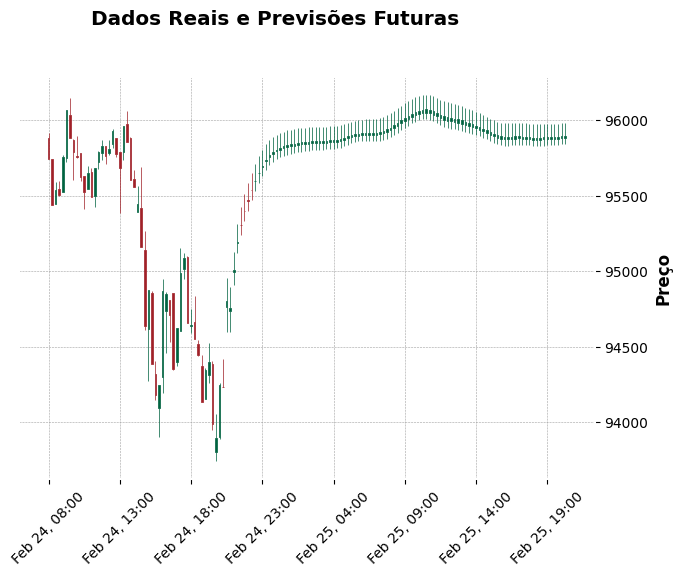

In [20]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import mplfinance as mpf
from ta.trend import EMAIndicator
from ta.momentum import RSIIndicator
from ta.volume import OnBalanceVolumeIndicator
from ta.volatility import BollingerBands
import matplotlib.pyplot as plt

# Função para carregar os dados do ativo
def carregar_dados_ativo(ticker, period, interval):
    try:
        dados = yf.download(ticker, period=period, interval=interval)
        if isinstance(dados.columns, pd.MultiIndex):
            dados.columns = [' '.join(col).strip() for col in dados.columns]
        colunas_esperadas = [f'{col} {ticker}' for col in ['Open', 'High', 'Low', 'Close', 'Volume']]
        if not set(colunas_esperadas).issubset(dados.columns):
            raise ValueError('Colunas esperadas não estão nos dados baixados')
        dados = dados[colunas_esperadas]
        dados.columns = ['Open', 'High', 'Low', 'Close', 'Volume']
        dados = dados.astype(float)
        return dados
    except Exception as e:
        print(f'Erro ao baixar os dados: {e}')
        raise

# Função para preparar os dados
def preparar_dados_candles(dados, lookback, target_cols):
    scaler_features = StandardScaler()
    scaler_targets = StandardScaler()
    features = dados.drop(columns=target_cols)
    targets = dados[target_cols]
    dados_features_normalizados = scaler_features.fit_transform(features)
    dados_targets_normalizados = scaler_targets.fit_transform(targets)
    X, y = [], []
    for i in range(lookback, len(dados_features_normalizados)):
        X.append(dados_features_normalizados[i-lookback:i, :])
        y.append(dados_targets_normalizados[i, :])
    return np.array(X), np.array(y), scaler_features, scaler_targets

# Função para criar modelo LSTM melhorado
def criar_modelo_lstm_targets(input_shape, output_size):
    model = Sequential([
        LSTM(units=100, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(units=100, return_sequences=False),
        Dropout(0.2),
        Dense(units=50, activation='relu'),
        Dense(units=output_size)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Parâmetros
ticker = "BTC-USD"
period = "60d"  # Período maior para mais dados históricos
interval = "15m"
lookback = 120

# Carregar os dados
dados = carregar_dados_ativo(ticker, period=period, interval=interval)

# Adicionar indicadores técnicos
dados['media curta'] = EMAIndicator(close=dados['Close'], window=3).ema_indicator()
dados['media longa'] = EMAIndicator(close=dados['Close'], window=9).ema_indicator()
dados['RSI'] = RSIIndicator(close=dados['Close'], window=14).rsi()
dados['On balance volume'] = OnBalanceVolumeIndicator(close=dados['Close'], volume=dados['Volume']).on_balance_volume()
bollinger = BollingerBands(close=dados['Close'], window=20, window_dev=2)
dados['bollinger_upper'] = bollinger.bollinger_hband()
dados['bollinger_lower'] = bollinger.bollinger_lband()
dados['bollinger_middle'] = bollinger.bollinger_mavg()

# Remover valores NaN
dados.dropna(inplace=True)

# Ajustar colunas de alvos e features
target_cols = ['Close', 'High', 'Low', 'Open']
X, y, scaler_features, scaler_targets = preparar_dados_candles(dados, lookback, target_cols)

# Dividir os dados em treino e teste
tamanho_treino = int(len(X) * 0.8)
tamanho_teste = len(X) - tamanho_treino
X_treino, X_teste = X[:tamanho_treino], X[tamanho_treino:]
y_treino, y_teste = y[:tamanho_treino], y[tamanho_treino:]

# Criar e treinar o modelo
modelo = criar_modelo_lstm_targets((X.shape[1], X.shape[2]), len(target_cols))
modelo.fit(X_treino, y_treino, epochs=100, batch_size=32, validation_data=(X_teste, y_teste), verbose=1)

# Fazer previsões para as próximas 24 horas (96 períodos de 15 minutos)
previsoes_futuras = []
ultimo_candle = X_teste[-1:].copy()  # Pega o último candle do conjunto de teste

# Índices das colunas de previsão dentro do dataset de features
indices_targets = [dados.columns.get_loc(col) for col in target_cols]

for _ in range(96):  # 96 períodos de 15 minutos para 24 horas
    previsao_normalizada = modelo.predict(ultimo_candle)

    # Converter de volta para valores reais
    previsao_real = scaler_targets.inverse_transform(previsao_normalizada)
    previsoes_futuras.append(previsao_real[0])

    # Criar novo candle para realimentar a previsão
    novo_candle = np.roll(ultimo_candle, shift=-1, axis=1)  # Move os candles para trás
    novo_candle[0, -1, indices_targets] = previsao_normalizada  # Adiciona a nova previsão normalizada

    ultimo_candle = novo_candle  # Atualiza o candle para a próxima previsão

# Converter previsões para DataFrame
previsoes_futuras = np.array(previsoes_futuras)
novo_datetime = pd.date_range(
    start=dados.index[-1] + pd.Timedelta(minutes=15),
    periods=96,
    freq='15T'
)
dados_candles_previsoes = pd.DataFrame(previsoes_futuras, columns=target_cols, index=novo_datetime)

# Concatenar os dados reais e as previsões
dados_plot = dados[['Open', 'High', 'Low', 'Close']].copy().iloc[-50:]
dados_plot = pd.concat([dados_plot, dados_candles_previsoes])

# Plotar os dados reais seguidos pelas previsões
fig, ax = mpf.plot(
    dados_plot,
    type='candle',
    style='charles',
    title='Dados Reais e Previsões Futuras',
    ylabel='Preço',
    volume=False,
    returnfig=True
)
plt.show()


In [9]:
plt.show()